In [1]:
!pwd

/workspace


In [2]:
# %%

import torch
from PIL import Image
import numpy as np
import skdim

from app import train_mood_space, interpolate_two_images

Loading pipeline components...: 100%|██████████| 5/5 [00:00<00:00, 11.45it/s]
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fai

In [3]:
# %%

from PIL import Image
path1 = "/workspace/images/dog1.jpg"
path2 = "/workspace/images/fish.jpg"
image1 = Image.open(path1).resize((512, 512), resample=Image.Resampling.LANCZOS).convert("RGB")
image2 = Image.open(path2).resize((512, 512), resample=Image.Resampling.LANCZOS).convert("RGB")

model, trainer = train_mood_space([image1, image2], lr=0.001, steps=1000)

Using cache found in /home/user/.cache/torch/hub/facebookresearch_dino_main
Loading pipeline components...: 100%|██████████| 5/5 [00:00<00:00, 12.74it/s]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name             | Type    | Params
---------------------------------------------
0 | compress         | MLP     | 1.3 M 
1 | uncompress       | MLPDown | 5.9 M 
2 | uncompress_dummy | MLP     | 1.3 M 
---------------------------------------------
8.4 M     Trainable params
0     

intrinsic dim is 9
Epoch 999: 100%|██████████| 1/1 [00:00<00:00,  6.97it/s, loss=0.00712, v_num=0, loss/eigvec=9.45e-7, loss/recon_fg=0.00651, loss/axis_align=0.033, loss/repulsion=0.603, loss/boundary=1.93e-5, loss/total=0.00658]  

`Trainer.fit` stopped: `max_steps=1000` reached.


Epoch 999: 100%|██████████| 1/1 [00:00<00:00,  6.93it/s, loss=0.00712, v_num=0, loss/eigvec=9.45e-7, loss/recon_fg=0.00651, loss/axis_align=0.033, loss/repulsion=0.603, loss/boundary=1.93e-5, loss/total=0.00658]


In [4]:
# %%

ws = np.linspace(0.0, 2.0, 10) # interpolation weight
interpolated_images = interpolate_two_images(image1, image2, model, ws, n_cluster=10, match_method='hungarian')

Using cache found in /home/user/.cache/torch/hub/facebookresearch_dino_main
100%|██████████| 50/50 [00:01<00:00, 34.93it/s]


In [5]:
# %%

def image_grid(imgs, rows, cols):
    assert len(imgs) == rows*cols

    w, h = imgs[0].size
    grid = Image.new('RGB', size=(cols*w, rows*h))
    grid_w, grid_h = grid.size
    
    for i, img in enumerate(imgs):
        grid.paste(img, box=(i%cols*w, i//cols*h))
    return grid

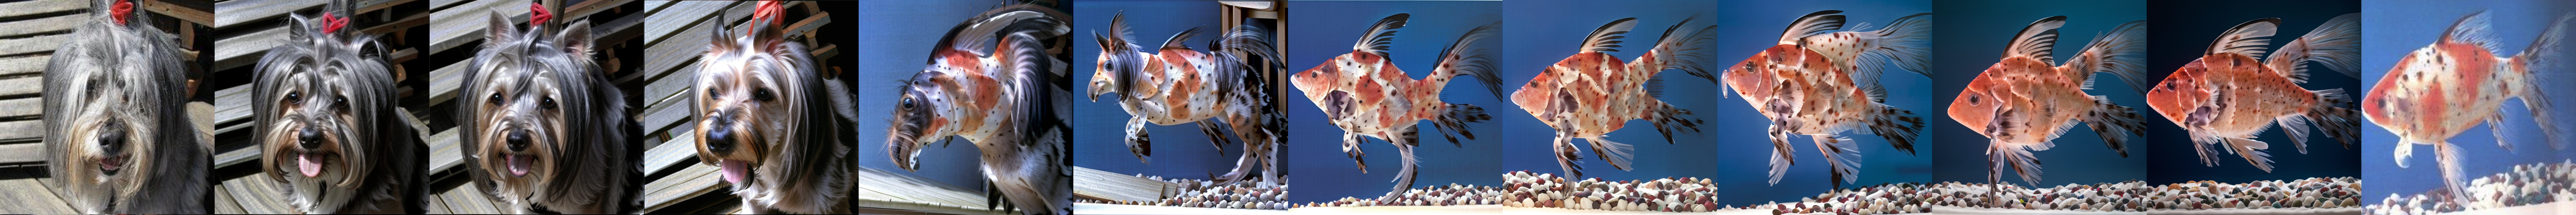

In [6]:
#%%

all_images = [image1] + interpolated_images + [image2]
img = image_grid(all_images, 1, len(all_images))
display(img)